# 1.RNA-seq

In [1]:
import numpy as np
import pandas as pd

import scanpy as sc
import scvelo as scv

import matplotlib.pyplot as plt
import seaborn as sns

import myutils

import random
import os

myutils.set_figure_params()
sc.settings.verbosity = 3

In [2]:
data_paths = ["../../Data/联川rna-seq/obs_2025_04_02_23_57_1/gene_count_matrix.txt","../../Data/联川rna-seq/obs_2025_04_02_23_57_48/gene_count_matrix.txt","../../Data/联川rna-seq/obs_2025_04_02_23_58_25/gene_count_matrix.txt"]
use_groups = ["NC_NHEK2","NC_NHEK1","NC5","NC6","NC7","OE10","OE4","OE5","OE6","OE_NHEK1"]
condition = ["CTRL"]*5 + ["FOSL1OE"] * 5
tmp = pd.read_csv("../../Data/ENSG_to_symbol.tsv",sep="\t")
tmp = tmp.iloc[:,:2]
tmp.columns = ["Gene","gene_id"]

adatas = []
for path in data_paths:
    adata = pd.read_csv(path,sep="\t",header=0)
    adata = pd.merge(tmp,adata,on="gene_id")
    adata.index = adata['Gene']
    adata=adata.drop(["Gene","gene_id"],axis='columns')
    adata = sc.AnnData(adata.T)
    adata.var_names_make_unique()
    adatas.append(adata)
adata = sc.concat(adatas)
adata = adata[use_groups]
adata.obs['sample'] = pd.Categorical(adata.obs_names.tolist())
adata.obs['condition'] = condition

del adatas, data_paths, condition,use_groups
print(adata)

AnnData object with n_obs × n_vars = 10 × 36259
    obs: 'sample', 'condition'


In [3]:
adata = adata[:,adata.X.sum(0) > 20]
adata = adata[:,~adata.var_names.str.startswith(("MT-","MIR","AL","LINC","AC"))]
dds_input = pd.DataFrame(adata.X,index=adata.obs_names,columns=adata.var_names)
adata

View of AnnData object with n_obs × n_vars = 10 × 16013
    obs: 'sample', 'condition'

In [4]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.tl.pca(adata,n_comps=2)

normalizing counts per cell
    finished (0:00:00)
computing PCA
    with n_comps=2
    finished (0:00:00)


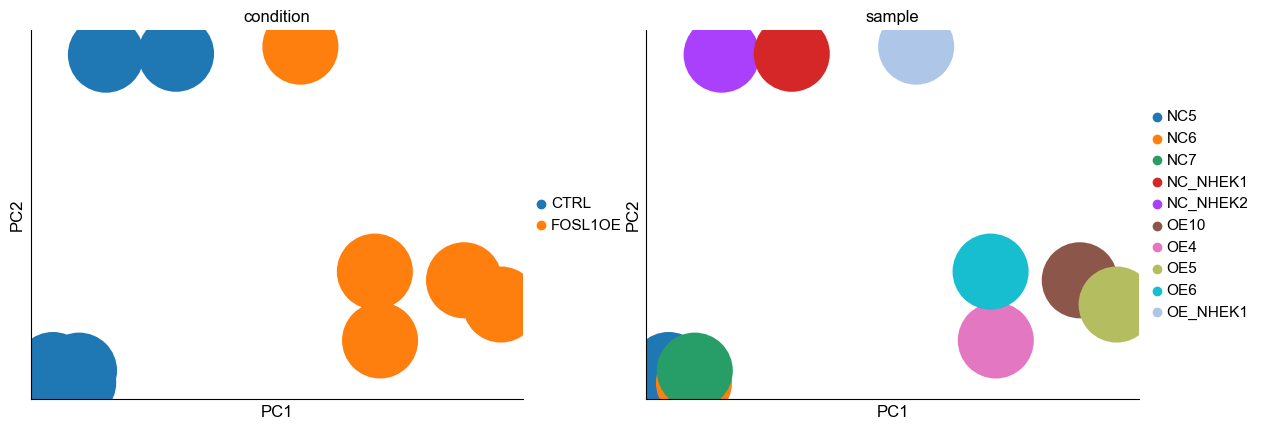

{'params': {'zero_center': True, 'use_highly_variable': False, 'mask_var': None}, 'variance': array([1413.8481,  893.5854], dtype=float32), 'variance_ratio': array([0.2785941 , 0.17607805], dtype=float32)}


In [6]:
sc.pl.pca(adata,color=["condition","sample"])
print(adata.uns['pca'])

In [7]:
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [8]:
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=dds_input,
    metadata=adata.obs,
    design_factors="condition",
    ref_level=["condition","CTRL"],
    refit_cooks=True,
    inference=inference,
)

In [9]:
dds.deseq2()

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.70 seconds.

Fitting dispersion trend curve...
... done in 0.54 seconds.

Fitting MAP dispersions...
... done in 2.08 seconds.

Fitting LFCs...
... done in 1.28 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.



In [10]:
stat_res = DeseqStats(
    dds,
    contrast=["condition", 'FOSL1OE', 'CTRL'],
    inference=inference,
)
stat_res

In [11]:
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition FOSL1OE vs CTRL
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Gene                                                                         
FAM87B      34.970388       -0.366799  0.671705 -0.546072  0.585016  0.797817
SAMD11     114.516329       -1.001763  0.414865 -2.414670  0.015749  0.084183
NOC2L    14413.928374        0.494786  0.157372  3.144043  0.001666  0.016105
KLHL17    1341.153878       -0.077116  0.247364 -0.311750  0.755230  0.894530
PLEKHN1    612.657611        0.386998  0.237880  1.626863  0.103766  0.295891
...               ...             ...       ...       ...       ...       ...
FAM224A     13.206552       -1.373937  0.670888 -2.047937  0.040566  0.162093
TTTY14      13.375391       -0.228736  1.143556 -0.200022  0.841464  0.935355
KDM5D     4476.091823       -0.450659  0.130349 -3.457329  0.000546  0.006828
EIF1AY    1220.233423        0.041907  0.171842  0.243868  0.807333  0.922352


... done in 0.63 seconds.



In [12]:
results_df = stat_res.results_df
results_df = results_df.sort_values(by="pvalue", axis=0, ascending=True)
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
COL5A1,4905.287567,-2.123261,0.146115,-14.531429,7.660592e-48,1.154298e-43
IGFN1,317.994156,6.748970,0.579751,11.641162,2.545241e-31,1.917585e-27
RDH10,2829.670145,-1.600165,0.138972,-11.514260,1.118156e-30,5.616124e-27
IL31RA,411.505266,3.775009,0.340837,11.075700,1.645893e-28,6.200078e-25
PPM1H,1373.084824,-1.349352,0.127292,-10.600447,2.965600e-26,8.937132e-23
...,...,...,...,...,...,...
SCIMP,8.813422,-0.966123,1.552673,-0.622232,NaN,NaN
AXIN2,4.075590,0.176036,2.701782,0.065155,NaN,NaN
ZNF750,647.742657,-0.875923,0.406214,-2.156310,NaN,NaN


In [13]:
results_df.to_csv("1.RNAseq_deseq2_results.tsv",sep="\t")

In [14]:
results_df.loc[["FOSL1","IL6R","MMP3"],:]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
FOSL1,79995.931031,6.864801,0.758290,9.053007,1.390848e-19,1.164294e-16
IL6R,2241.463995,1.167322,0.284412,4.104339,4.054731e-05,8.728099e-04
MMP3,14.109382,2.873177,0.972733,2.953715,3.139741e-03,2.617672e-02


In [15]:
import decoupler as dc

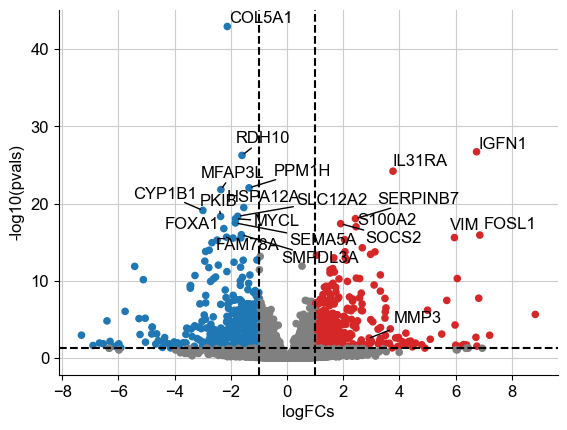

In [16]:
fig,ax = plt.subplots()
dc.plot_volcano_df(
    results_df,
    x='log2FoldChange',
    y='padj',
    top=20,
    figsize=(8, 4),
    ax=ax,
    lFCs_thr=1,
    sign_thr=0.05
)
ax.annotate("MMP3", (2.873177, -np.log10(3.139741e-03)),xytext=(3.8,4.5),arrowprops={"arrowstyle":"-"})
fig.savefig("1.Figure5A.pdf",format="pdf",bbox_inches="tight")
plt.show()

In [17]:
msigdb = dc.read_gmt("../../Data/msigdb_v2024.1.Hs_GMTs/c5.go.bp.v2024.1.Hs.symbols.gmt")
msigdb = msigdb[~msigdb.duplicated(['source',"target"])]
tmp = []
for i in msigdb['source']:
    if "_" in i:
        tmp.append(i[:i.find("_")])
    else:
        tmp.append(i)
msigdb['collection']=tmp
print(msigdb['collection'].unique().tolist())

['GOBP']


In [18]:
enr_pvals = dc.get_ora_df(
    df=results_df.loc[results_df['log2FoldChange']>0.5].head(400).index.tolist(),
    net=msigdb, 
    source='source',
    target='target',
)
enr_pvals = enr_pvals.sort_values("FDR p-value",ascending=True)
enr_pvals["-log10 p-value"] = - np.log10(enr_pvals['p-value'])
enr_pvals['Term2'] = [i.replace("GOBP_", "") for i in enr_pvals['Term']]
enr_pvals['Term2'] = [i.replace("_", " ") for i in enr_pvals['Term2']]
enr_pvals['Term2'] = [i.lower() for i in enr_pvals['Term2']]
enr_pvals

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features,-log10 p-value,Term2
152,GOBP_ATTACHMENT_OF_SPINDLE_MICROTUBULES_TO_KIN...,53,0.169811,9.526467e-07,0.003610,9.047457,125.434141,CDCA8;CENPE;ECT2;KIF2C;KNSTRN;NDC80;NEK2;RACGA...,6.021068,attachment of spindle microtubules to kinetochore
1235,GOBP_METAPHASE_CHROMOSOME_ALIGNMENT,103,0.106796,6.854077e-06,0.008657,5.676080,67.492382,CDCA8;CENPE;ECT2;GEM;KIF18A;KIF2C;KNSTRN;NDC80...,5.164051,metaphase chromosome alignment
3408,GOBP_RESPONSE_TO_WOUNDING,574,0.050523,5.262887e-06,0.008657,2.685145,32.637482,ADTRP;ANXA2;AURKA;AXL;BNIP3;CD44;DCBLD2;DDIT3;...,5.278776,response to wounding
1280,GOBP_MITOTIC_NUCLEAR_DIVISION,283,0.063604,1.736339e-05,0.011400,3.363869,36.871861,ANLN;AURKA;CDCA2;CDCA8;CENPE;KIF18A;KIF2C;KNST...,4.760365,mitotic nuclear division
1833,GOBP_ORGANELLE_FISSION,498,0.050201,2.630067e-05,0.011400,2.656779,28.018164,ANLN;AURKA;BNIP3;CCNB2;CDCA2;CDCA8;CENPE;CORO1...,4.580033,organelle fission
...,...,...,...,...,...,...,...,...,...,...
565,GOBP_DETECTION_OF_STIMULUS,676,0.007396,9.978836e-01,0.998938,0.397243,0.000842,NTSR1;PLEKHB1;RYR2;SRPX;SYT1,0.000920,detection of stimulus
884,GOBP_G_PROTEIN_COUPLED_RECEPTOR_SIGNALING_PATHWAY,1321,0.009841,9.990269e-01,0.999819,0.492448,0.000479,ADRB2;AKAP12;DGKA;GPR176;GPR19;HIF1A;NTSR1;OXT...,0.000423,g protein coupled receptor signaling pathway
3481,GOBP_SENSORY_PERCEPTION,989,0.008089,9.993385e-01,0.999866,0.416083,0.000275,DDIT3;EYA1;FABP5;GJC1;NTSR1;RPL38;TIMM10;TIMM9,0.000287,sensory perception
566,GOBP_DETECTION_OF_STIMULUS_INVOLVED_IN_SENSORY...,552,0.001812,9.999878e-01,0.999988,0.132169,0.000002,NTSR1,0.000005,detection of stimulus involved in sensory perc...


In [21]:
#https://cn.string-db.org/ STRINGdb analysis
pd.DataFrame(results_df.loc[results_df['log2FoldChange']>0.5].head(400).index.tolist()).to_csv("1.string_analysis.csv",index=None,header=None)

In [23]:
# two candidate GO pathway genesets
GO_wounding = "ADTRP;ANXA2;AURKA;AXL;BNIP3;CD44;DCBLD2;DDIT3;DGKA;ELK3;FKBP10;FOSL1;FOXA2;HBEGF;HIF1A;INHBA;LCP1;NRG1;NRP1;PRKCA;SERPINA1;SERPINB2;SERPINE1;TFPI;THBS1;TNC;TNFAIP3;UBASH3B;VAV1"
GO_wounding = GO_wounding.split(";")
GO_motility = "ABL2;ADAM9;ADAMTS1;ADAMTS9;ADTRP;AKAP12;ANLN;ANXA3;AXL;CD44;CORO1C;DCLK1;DDIT3;DNAH5;DNER;DOCK10;ECM1;EFNB1;EFNB2;ETS1;GADD45A;GPSM3;HBEGF;HDAC9;HIF1A;HMGB2;IL6R;KNSTRN;LAMA3;LAMC2;LCP1;LIMA1;LOX;MEAK7;NAV3;NFATC2;NRP1;PRKCA;PTPRB;PTPRR;RND3;S100A2;SCG2;SEMA7A;SERPINE1;SGK1;SH3KBP1;SMURF2;SOX9;SPATA13;SPOCK1;TCAF2;THBS1;TNC;TNFAIP3;TRIB1;TRIM55;VAV1"
GO_motility = GO_motility.split(";")
GO_motility = results_df.loc[GO_motility].head(30).index.tolist()
print(len(GO_wounding),len(GO_motility))

29 30


In [26]:
# FigureS4A for cytoscape visualization
tmp = pd.read_csv("string_node_degrees.tsv",sep="\t",header=0)
index = [i in results_df.index for i in tmp['#node']]
tmp.index = tmp["#node"]
tmp = tmp[index]
tmp['log2foldchange'] = results_df.loc[tmp.index,"log2FoldChange"]
tmp['is_wounding'] = False
index = [i in GO_wounding for i in tmp.index]
tmp.loc[index,"is_wounding"] = True
tmp['is_motility'] = False
index = [i in GO_motility for i in tmp.index]
tmp.loc[index,"is_motility"] = True

edges = pd.read_csv("string_interactions.tsv",sep="\t",header=0)
use = "is_wounding"
tmp2 = edges.loc[ [i in tmp.loc[tmp[use]].index for i in edges["#node1"]] , :]
tmp2 = tmp2.loc[ [i in tmp.loc[tmp[use]].index for i in tmp2["node2"]] , :]
a = tmp.loc[tmp2["#node1"],:]
a.index= list(range(a.shape[0]))
tmp2.index = list(range(tmp2.shape[0]))
pd.concat((tmp2, a), axis=1).to_csv("string_"+use+".tsv",sep="\t")

use = "is_motility"
tmp2 = edges.loc[ [i in tmp.loc[tmp[use]].index for i in edges["#node1"]] , :]
tmp2 = tmp2.loc[ [i in tmp.loc[tmp[use]].index for i in tmp2["node2"]] , :]
a = tmp.loc[tmp2["#node1"],:]
a.index= list(range(a.shape[0]))
tmp2.index = list(range(tmp2.shape[0]))
pd.concat((tmp2, a), axis=1).to_csv("string_"+use+".tsv",sep="\t")

tmp = tmp.loc[np.logical_or(tmp['is_wounding'],tmp['is_motility'])]

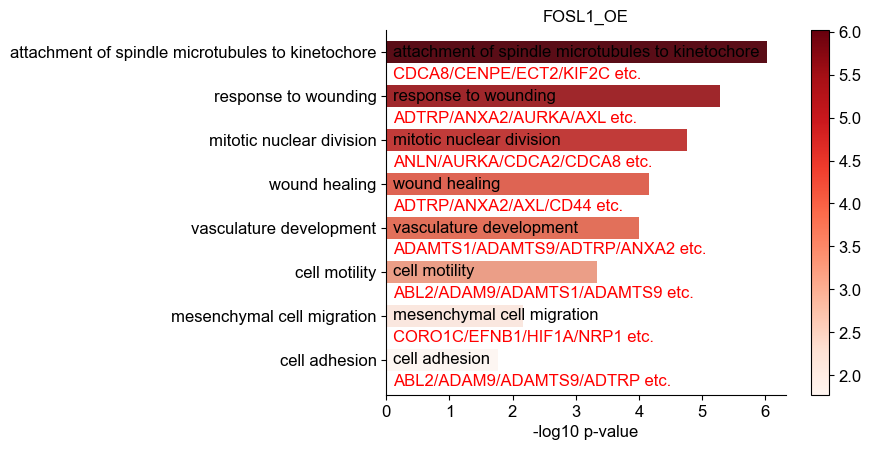

In [27]:
use_paths = ["attachment of spindle microtubules to kinetochore","response to wounding","cell adhesion","wound healing","cytoskeleton organization""positive regulation of epithelial cell migration","mitotic nuclear division","vasculature development","cell motility","mesenchymal cell migration"]
tmp = enr_pvals[enr_pvals['Term2'].isin(use_paths)]
a = tmp["-log10 p-value"]/tmp["-log10 p-value"].max()
c = list(plt.cm.Reds(a))
fig,ax=plt.subplots()
# Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.
ax = sns.barplot(data=tmp,y="Term2",x="-log10 p-value",orient="h",hue="-log10 p-value",palette='Reds',width=0.5)
for i in range(tmp.shape[0]):
    ax.text(x=0.1,y=i+0.1,s=tmp.iloc[i,:]['Term2'],color="black")
    tmp2 = tmp.iloc[i,7]
    tmp2 = tmp2.split(";")[:4]
    tmp2 = "/".join(tmp2)
    tmp2 = tmp2 + " etc."
    ax.text(x=0.1,y=i+0.6,s=tmp2,color="red")
ax.set_ylim(-0.5,7.8)
ax.yaxis.set_inverted(True)
ax.grid(False)
plt.ylabel("")
plt.title("FOSL1_OE")
ax.get_legend().remove()

norm = plt.Normalize(tmp["-log10 p-value"].min(), tmp["-log10 p-value"].max())
sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
ax.figure.colorbar(sm, ax=ax)

fig.savefig("1.Figure5B.pdf",format="pdf",bbox_inches="tight")
plt.show()

In [28]:
enr_pvals = dc.get_ora_df(
    df=results_df.loc[results_df['log2FoldChange']<-0.5].head(400).index.tolist(),
    net=msigdb, 
    source='source',
    target='target',
)
enr_pvals = enr_pvals.sort_values("FDR p-value",ascending=True)
enr_pvals["-log10 p-value"] = - np.log10(enr_pvals['p-value'])
enr_pvals['Term2'] = [i.replace("GOBP_", "") for i in enr_pvals['Term']]
enr_pvals['Term2'] = [i.replace("_", " ") for i in enr_pvals['Term2']]
enr_pvals['Term2'] = [i.lower() for i in enr_pvals['Term2']]
enr_pvals

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features,-log10 p-value,Term2
869,GOBP_GENERATION_OF_NEURONS,1510,0.049669,1.486596e-13,4.107658e-10,2.839382,8.386717e+01,ANK3;APP;ARHGEF40;B3GNT2;B4GALT5;BBS1;BCL6;BEN...,1.282781e+01,generation of neurons
759,GOBP_EPITHELIUM_DEVELOPMENT,1236,0.053398,2.139405e-13,4.107658e-10,3.016952,8.801378e+01,AGR2;AKR1C1;AKR1C2;AKR1C3;ASAH1;BMP2;BMP4;BMP7...,1.266971e+01,epithelium development
85,GOBP_ANIMAL_ORGAN_MORPHOGENESIS,1029,0.056365,8.334279e-13,1.066788e-09,3.147535,8.754312e+01,ATP6V1B1;BBS1;BCL2L11;BMP2;BMP4;BMP7;COL18A1;C...,1.207913e+01,animal organ morphogenesis
1798,GOBP_NEUROGENESIS,1745,0.045845,1.319969e-12,1.267170e-09,2.626889,7.185438e+01,ANK3;APP;ARHGEF40;B3GNT2;B4GALT5;BBS1;BCL6;BEN...,1.187944e+01,neurogenesis
878,GOBP_GLAND_DEVELOPMENT,449,0.071269,5.824469e-10,4.473192e-07,3.836156,8.157119e+01,APLN;BCL2L11;BMP2;BMP4;BMP7;CDKN2B;CLDN1;CYP1A...,9.234744e+00,gland development
...,...,...,...,...,...,...,...,...,...,...
3510,GOBP_SENSORY_PERCEPTION_OF_SMELL,456,0.004386,9.990566e-01,1.000000e+00,0.268593,2.535227e-04,B3GNT2;BBS1,4.099262e-04,sensory perception of smell
3478,GOBP_RNA_PROCESSING,1423,0.002811,1.000000e+00,1.000000e+00,0.148115,9.151425e-11,BMP4;PIK3R1;RBPMS;TRMT9B,2.683329e-10,rna processing
591,GOBP_DETECTION_OF_STIMULUS,676,0.004438,9.998920e-01,1.000000e+00,0.251519,2.716160e-05,CLEC7A;OPN3;PKD2,4.689951e-05,detection of stimulus
1857,GOBP_NUCLEIC_ACID_CATABOLIC_PROCESS,802,0.003741,9.999893e-01,1.000000e+00,0.210646,2.254530e-06,IREB2;PRR5L;TRMT9B,4.648224e-06,nucleic acid catabolic process


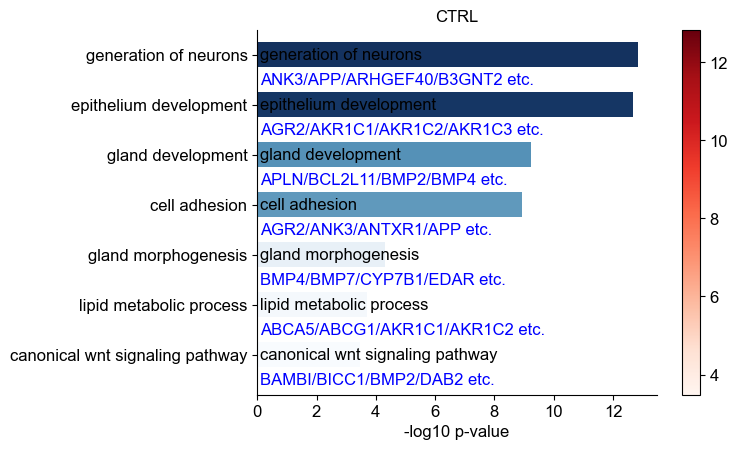

In [29]:
use_paths = ["generation of neurons","epithelium development","gland development","cell adhesion","gland morphogenesis","lipid metabolic process","canonical wnt signaling pathway"]
tmp = enr_pvals[enr_pvals['Term2'].isin(use_paths)]
a = tmp["-log10 p-value"]/tmp["-log10 p-value"].max()
c = list(plt.cm.Blues(a))
fig,ax=plt.subplots()
# Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.
ax = sns.barplot(data=tmp,y="Term2",x="-log10 p-value",orient="h",hue="-log10 p-value",palette='Blues',width=0.5)
for i in range(tmp.shape[0]):
    ax.text(x=0.1,y=i+0.1,s=tmp.iloc[i,:]['Term2'],color="black")
    tmp2 = tmp.iloc[i,7]
    tmp2 = tmp2.split(";")[:4]
    tmp2 = "/".join(tmp2)
    tmp2 = tmp2 + " etc."
    ax.text(x=0.1,y=i+0.6,s=tmp2,color="blue")
ax.set_ylim(-0.5,6.8)
ax.yaxis.set_inverted(True)
ax.grid(False)
plt.ylabel("")
plt.title("CTRL")
ax.get_legend().remove()

norm = plt.Normalize(tmp["-log10 p-value"].min(), tmp["-log10 p-value"].max())
sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
ax.figure.colorbar(sm, ax=ax)

fig.savefig("1.Figure5C.pdf",format="pdf",bbox_inches="tight")
plt.show()

In [30]:
!conda list

# packages in environment at C:\Users\dell\.conda\envs\scanpy:
#
# Name                    Version                   Build  Channel
absl-py                   2.3.0                    pypi_0    pypi
adjusttext                1.3.0                    pypi_0    pypi
aiobotocore               2.5.4                    pypi_0    pypi
aiohappyeyeballs          2.6.1                    pypi_0    pypi
aiohttp                   3.12.4                   pypi_0    pypi
aioitertools              0.12.0                   pypi_0    pypi
aiosignal                 1.3.2                    pypi_0    pypi
anndata                   0.10.8                   pypi_0    pypi
anyio                     4.8.0                    pypi_0    pypi
argon2-cffi               23.1.0                   pypi_0    pypi
argon2-cffi-bindings      21.2.0                   pypi_0    pypi
array-api-compat          1.10.0                   pypi_0    pypi
arrow                     1.3.0                    pypi_0    pypi
asciitree 